In [8]:
# importing libraries and functions
import os
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy.stats import zscore
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
import re
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb


In [9]:

def doy_to_datetime(year: int, doy: int, hour: int, minute: int, second: float=0.0):
    return datetime(year, 1, 1) + timedelta(days=doy - 1, hours=hour, minutes=minute, seconds=second)

def parse_fengyun_line(line: str):
    pattern = r'(\S+)\s+(\S+)\s+"([^"]+)"\s+"([^"]+)"'
    match = re.match(pattern, line)
    if not match:
        print(f"Line did not match Fengyun format: {line}")
        return None

    sat_code = match.group(1)
    sat_id = f"{sat_code} {match.group(2)}"
    start_str = match.group(3).split()[0]  # Remove timezone if present
    end_str = match.group(4).split()[0]

    try:
        start_dt = datetime.fromisoformat(start_str)
        end_dt = datetime.fromisoformat(end_str)
    except Exception as e:
        print(f"Error parsing timestamps: {line}\n{e}")
        return None

    return {'satellite': sat_id, 'start_time': start_dt, 'end_time': end_dt}

def process_fengyun_manoeuvre_file(filepath: str):
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = parse_fengyun_line(line)
            if rec:
                records.append(rec)
    return pd.DataFrame(records)

def load_orbital_elements(filepath: str):
    try:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
        df.sort_index(inplace=True)
        df.index.name = 'timestamp'  # renamed from 'epoch' to 'timestamp'
        return df
    except Exception as e:
        print(f"Error loading orbital elements file: {filepath}\n{e}")
        return pd.DataFrame()

def main():
    base_dir = './satellite_data'
    manoeuvre_file = os.path.join(base_dir, 'manoeuvres', 'manFY2D.txt.fy')
    orbital_file = os.path.join(base_dir, 'orbital_elements', 'Fengyun-2D.csv')

    # Process Fengyun manoeuvre file
    print(f"Processing Fengyun manoeuvre file: {manoeuvre_file}")
    df_manoeuvre = process_fengyun_manoeuvre_file(manoeuvre_file)
    print("Fengyun manoeuvre data:")
    print(df_manoeuvre.head())

    # Process Fengyun orbital elements file
    print(f"Processing Fengyun orbital elements file: {orbital_file}")
    df_orbital = load_orbital_elements(orbital_file)
    print("Fengyun orbital element data:")
    print(df_orbital.head())

    return df_manoeuvre, df_orbital

    return man_df, orb_df 

In [10]:
man_df, orb_df = main()

Processing Fengyun manoeuvre file: ./satellite_data/manoeuvres/manFY2D.txt.fy
Fengyun manoeuvre data:
                          satellite          start_time            end_time
0  GEO-EW-STATION-KEEPING 2006-053A 2015-04-10 15:30:00 2015-04-10 16:30:00
1  GEO-EW-STATION-KEEPING 2006-053A 2015-01-27 14:30:00 2015-01-27 15:30:00
2  GEO-EW-STATION-KEEPING 2006-053A 2014-10-24 15:30:00 2014-10-24 16:30:00
3  GEO-EW-STATION-KEEPING 2006-053A 2014-08-04 15:30:00 2014-08-04 16:30:00
4  GEO-EW-STATION-KEEPING 2006-053A 2014-05-09 15:30:00 2014-05-09 16:30:00
Processing Fengyun orbital elements file: ./satellite_data/orbital_elements/Fengyun-2D.csv
Fengyun orbital element data:
                            eccentricity  argument of perigee  inclination  \
timestamp                                                                    
2011-01-27 14:08:12.153119      0.000146             5.402166     0.020778   
2011-01-28 17:37:05.756160      0.000155             5.423049     0.020839   
2011-01-2

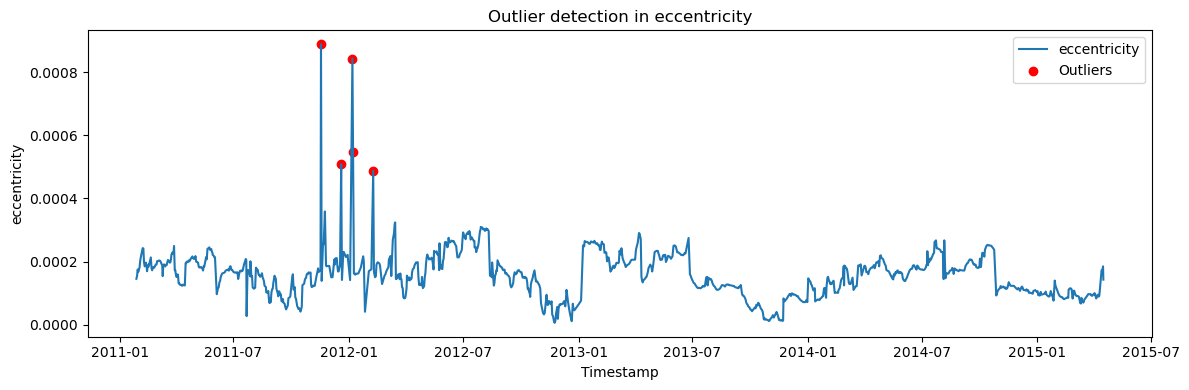

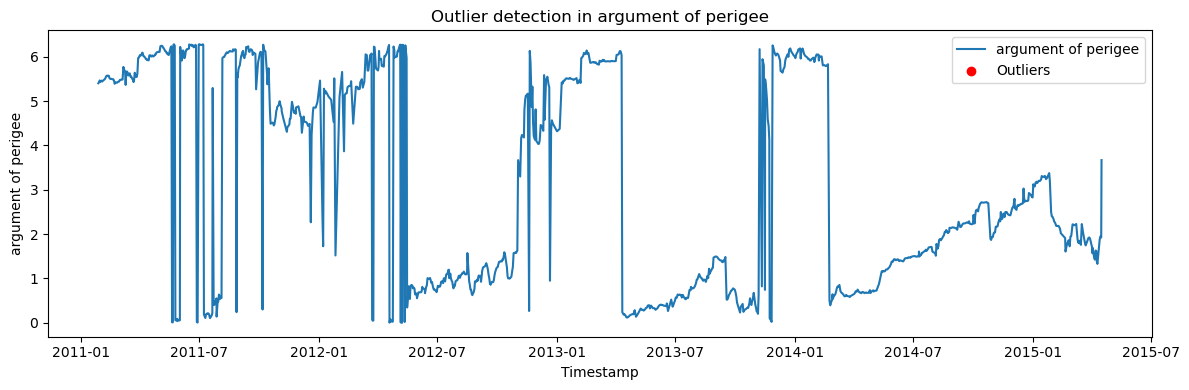

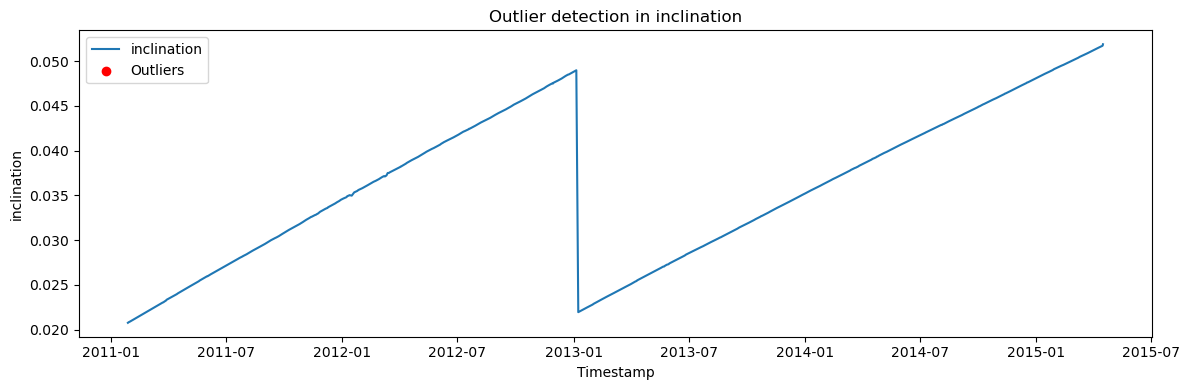

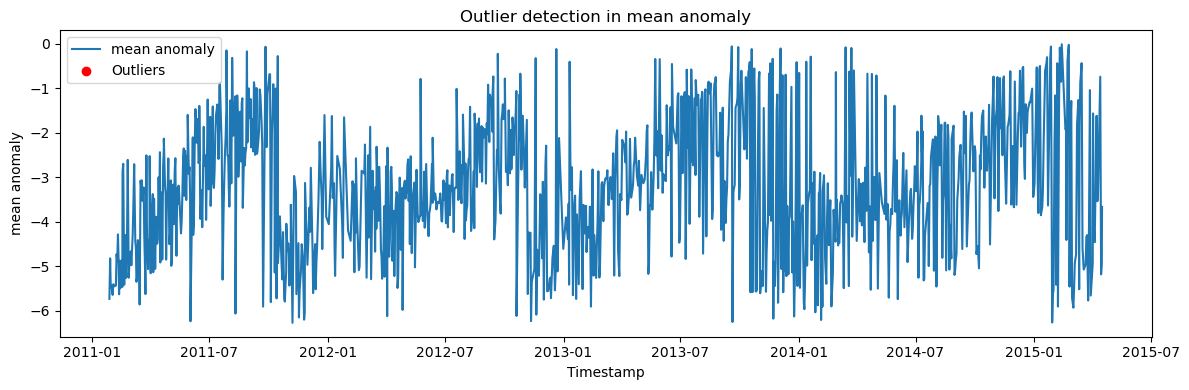

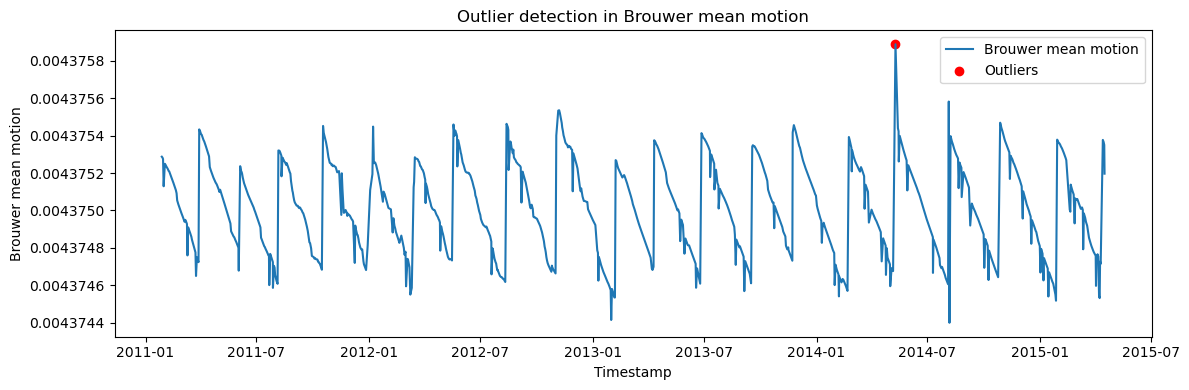

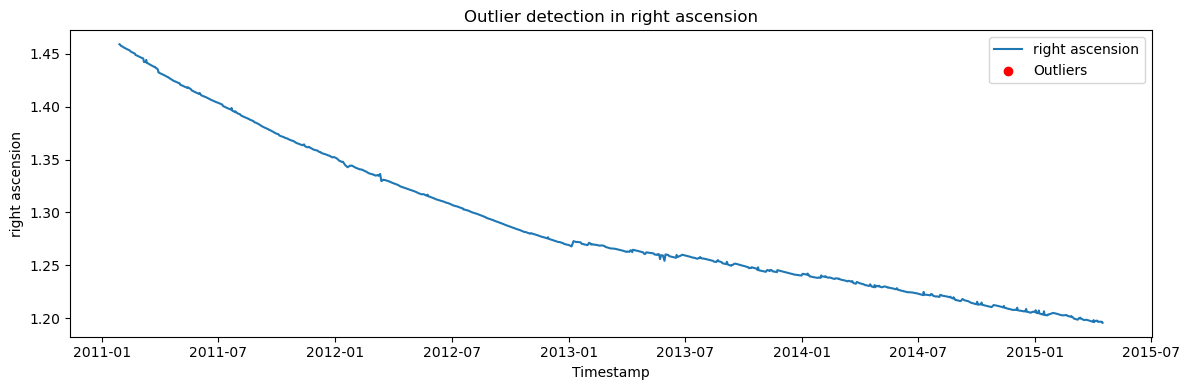

In [11]:
#Detecting outliers

def detect_outliers(df, threshold=3):
    z_scores = df.apply(zscore)  # Z-score across columns
    outliers = (z_scores.abs() > threshold)
    return outliers

def plot_outliers(df, outliers):
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(df.index, df[col], label=col)
        plt.scatter(df.index[outliers[col]], df[col][outliers[col]], color='red', label='Outliers')
        plt.title(f"Outlier detection in {col}")
        plt.legend()
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
outliers = detect_outliers(orb_df)
plot_outliers(orb_df, outliers)


--- Descriptive Statistics ---
       eccentricity  argument of perigee  inclination  mean anomaly  \
count   1187.000000          1187.000000  1187.000000   1187.000000   
mean       0.000159             3.142386     0.035877     -3.193376   
std        0.000071             2.304360     0.008510      1.465265   
min        0.000006             0.000339     0.020778     -6.272115   
25%        0.000115             0.932269     0.028463     -4.295577   
50%        0.000160             2.339151     0.036228     -3.237645   
75%        0.000199             5.722917     0.043127     -2.122498   
max        0.000888             6.281613     0.051880     -0.006215   

       Brouwer mean motion  right ascension  
count         1.187000e+03      1187.000000  
mean          4.375016e-03         1.292740  
std           2.366158e-07         0.073150  
min           4.374399e-03         1.195585  
25%           4.374820e-03         1.235582  
50%           4.375012e-03         1.269402  
75%   

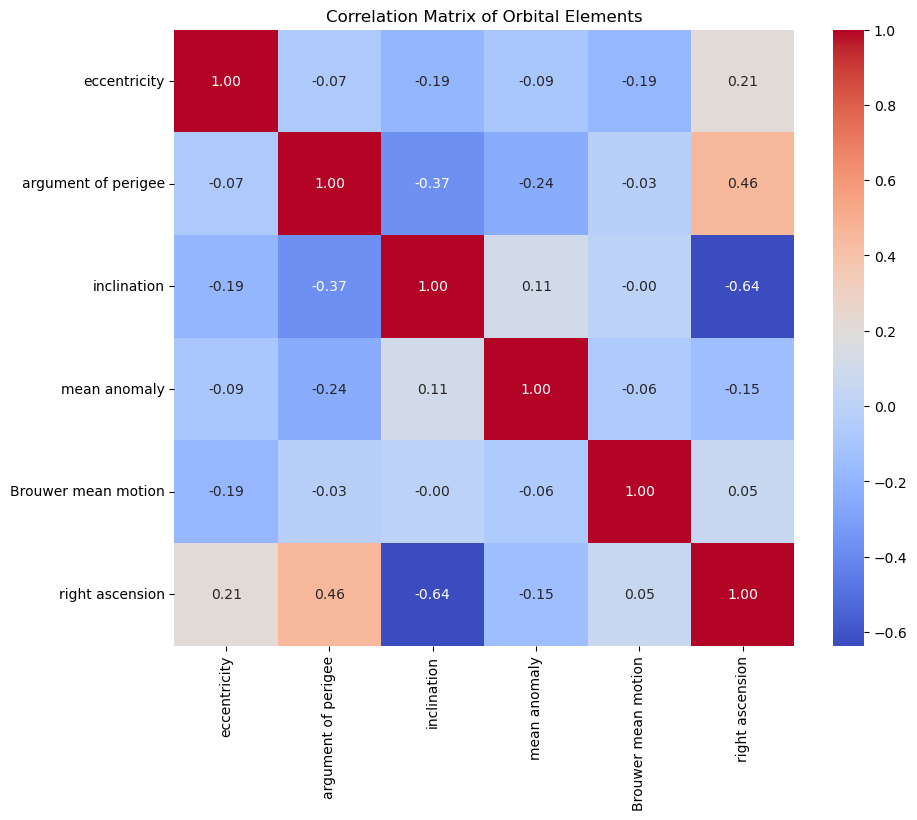

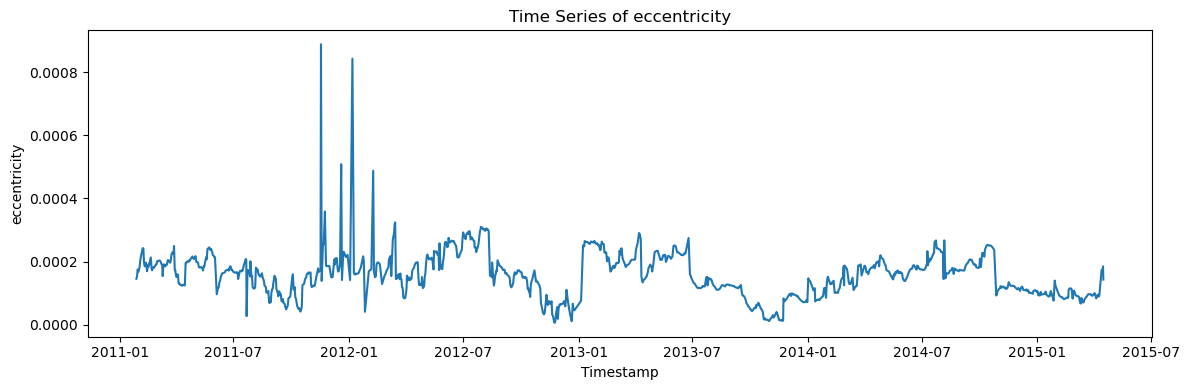

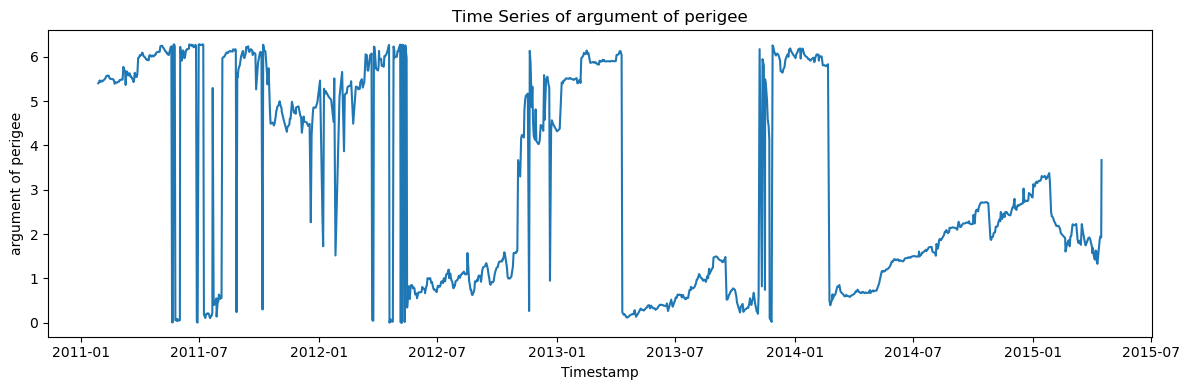

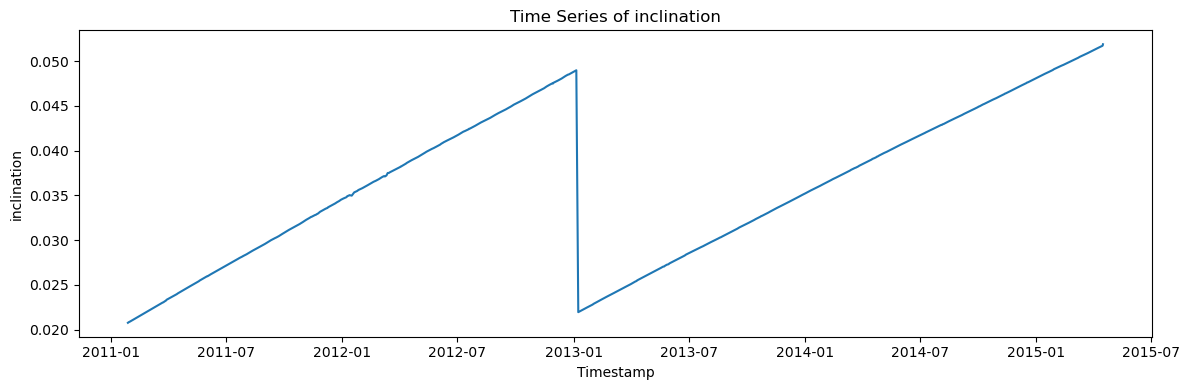

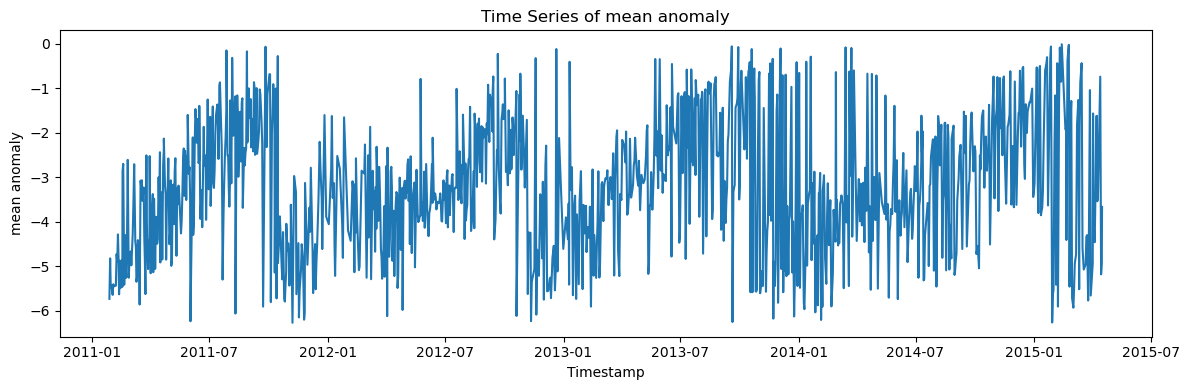

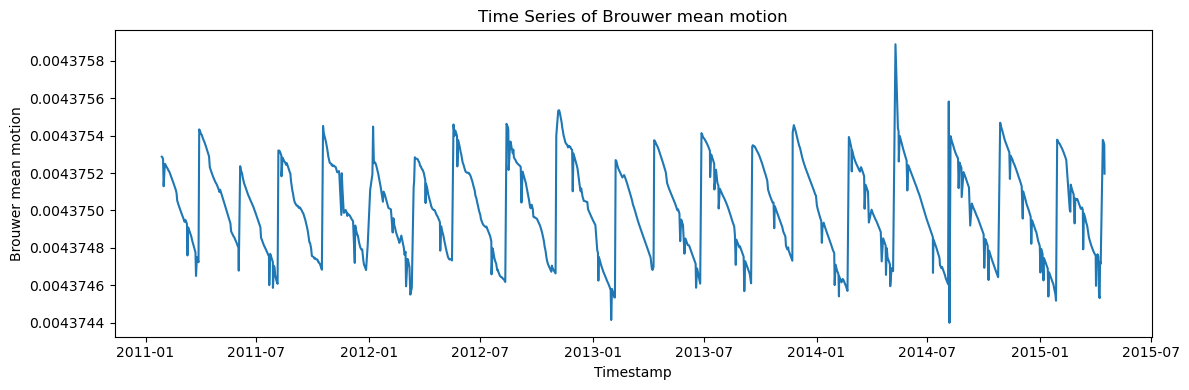

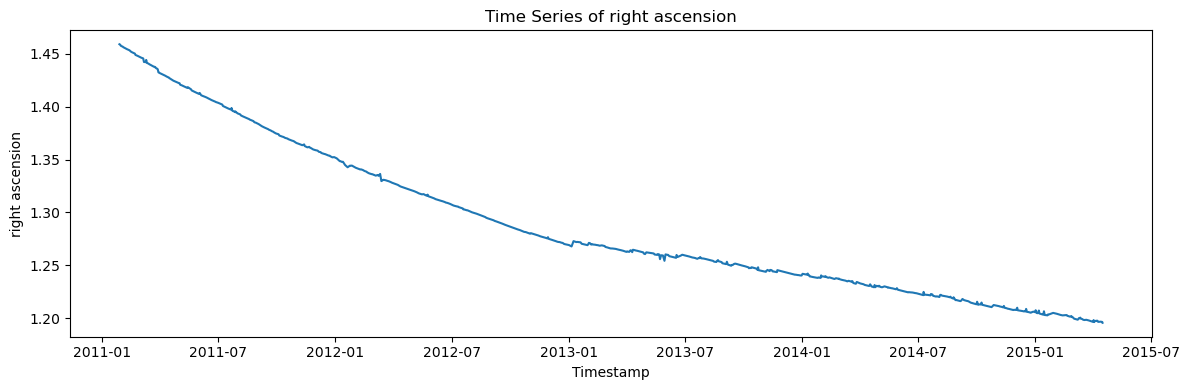

In [25]:
# EDA for orbital elements

def exploratory_analysis(df):
    print("\n--- Descriptive Statistics ---")
    print(df.describe())

    print("\n--- Null Values ---")
    print(df.isnull().sum())

    print("\n--- Correlation Matrix ---")
    corr = df.corr()
    print(corr)

    # Heatmap of correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Orbital Elements")
    plt.show()

    # Time-series trend plot
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        sns.lineplot(x=df.index, y=df[col])
        plt.title(f"Time Series of {col}")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
exploratory_analysis(orb_df)

<Figure size 1000x400 with 0 Axes>

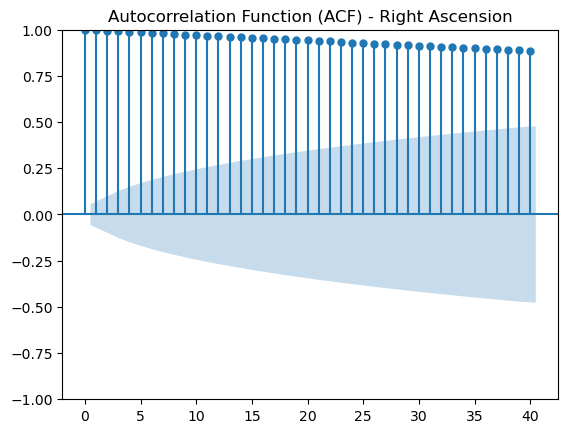

<Figure size 1000x400 with 0 Axes>

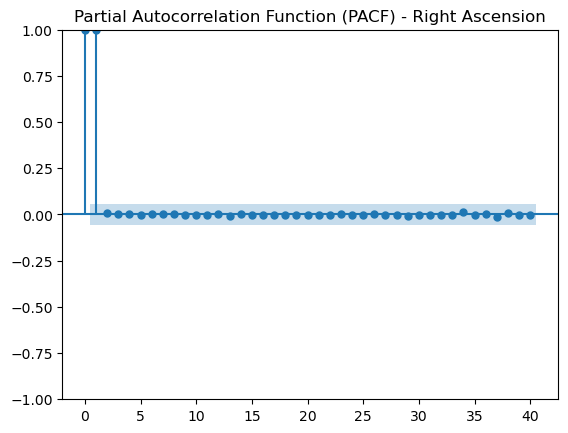


 ADF Test ---
ADF Statistic     : -9.427151
p-value           : 0.000000
Critical Values   :
   1%: -3.4359
   5%: -2.8640
   10%: -2.5681

 The series is stationary.


In [12]:
# EDA for 'right ascension'

series = orb_df['right ascension'].dropna()

# ACF plot
plt.figure(figsize=(10, 4))
plot_acf(series, lags=40)
plt.title('Autocorrelation Function (ACF) - Right Ascension')
plt.show()

# PACF plot
plt.figure(figsize=(10, 4))
plot_pacf(series, lags=40, method='ywm') 
plt.title('Partial Autocorrelation Function (PACF) - Right Ascension')
plt.show()

# ADF Test
result = adfuller(series)
print('\n ADF Test ---')
print(f"ADF Statistic     : {result[0]:.6f}")
print(f"p-value           : {result[1]:.6f}")
print(f"Critical Values   :")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] < 0.05:
    print("\n The series is stationary.")
else:
    print("\n The series is NOT stationary.")


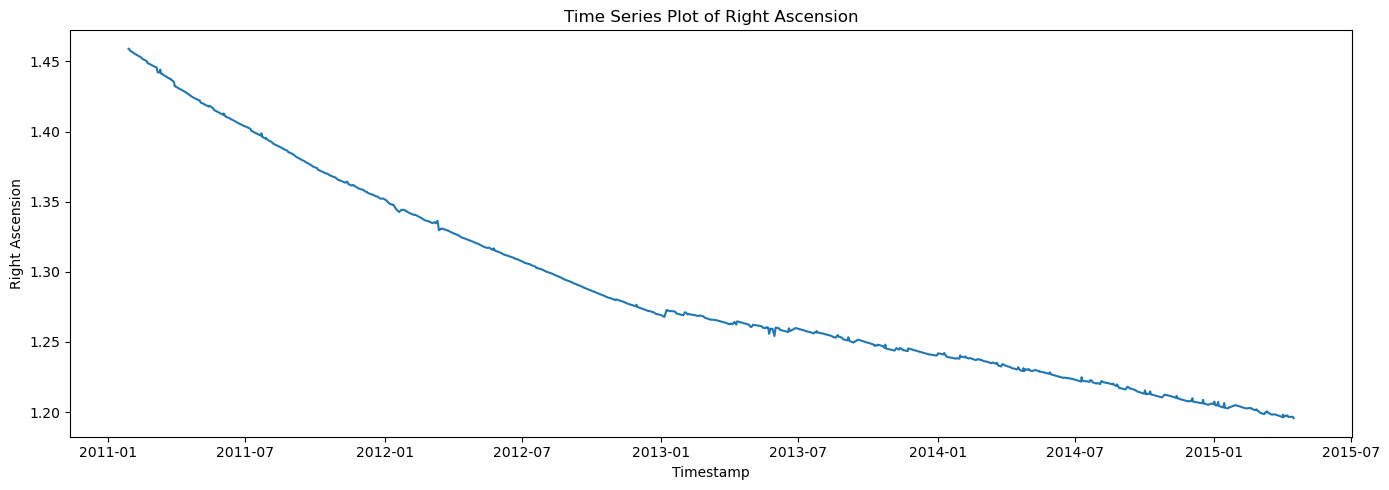

In [13]:
# time series to observe trends/seasonality for 'right ascension'
def plot_right_ascension_trend(df):
    if 'right ascension' not in df.columns:
        print("Column 'right ascension' not found in dataframe.")
        return   
    plt.figure(figsize=(14, 5))
    sns.lineplot(x=df.index, y=df['right ascension'])
    plt.title("Time Series Plot of Right Ascension")
    plt.xlabel("Timestamp")
    plt.ylabel("Right Ascension")
    plt.tight_layout()
    plt.show()
plot_right_ascension_trend(orb_df)


In [14]:
# Resample to daily frequency
ra_daily = orb_df['right ascension'].resample('D').mean().ffill()

# Use the resampled series
series = ra_daily.dropna()

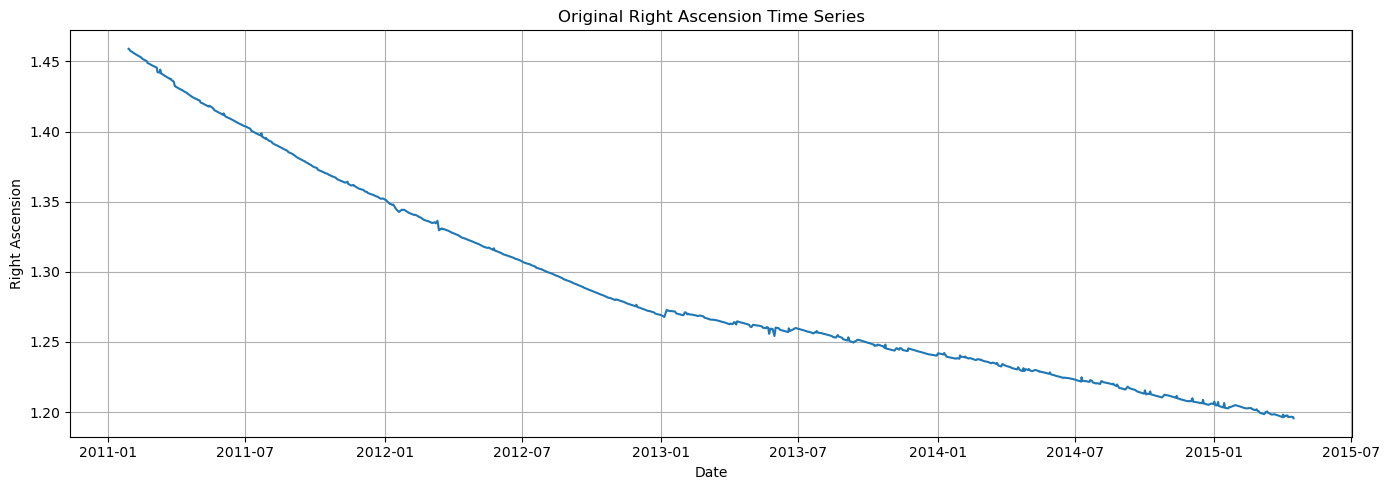

=== Original Right Ascension ===
ADF Statistic: -9.4272
p-value: 0.0000
Result: Stationary




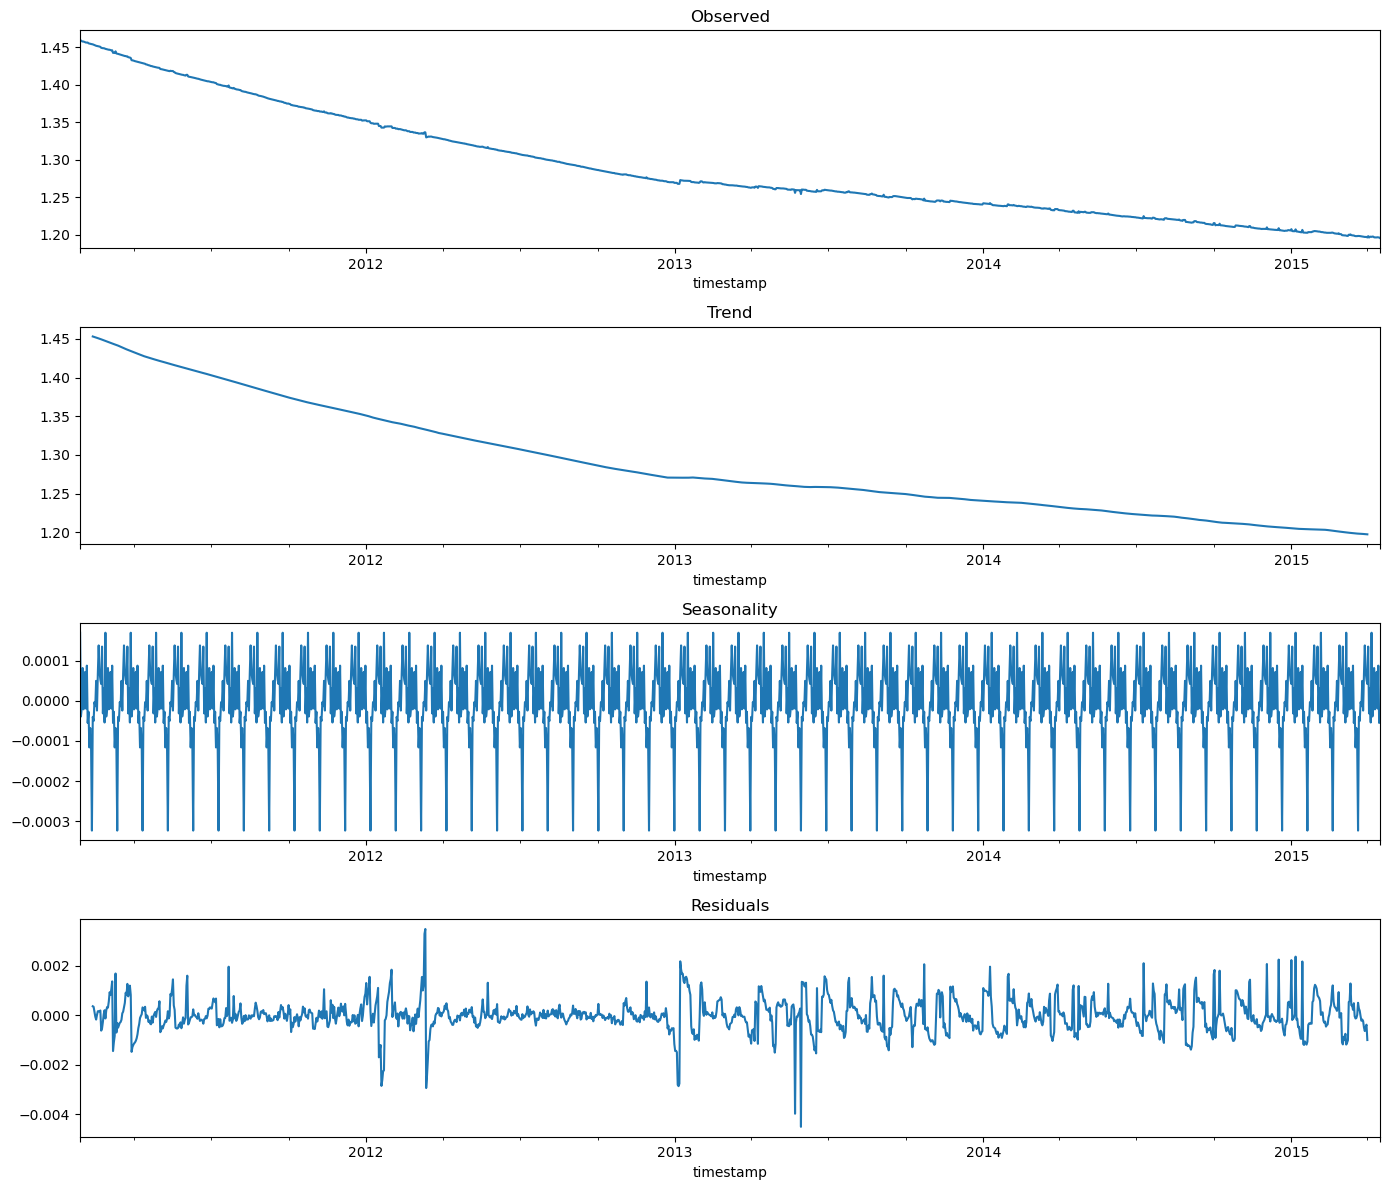

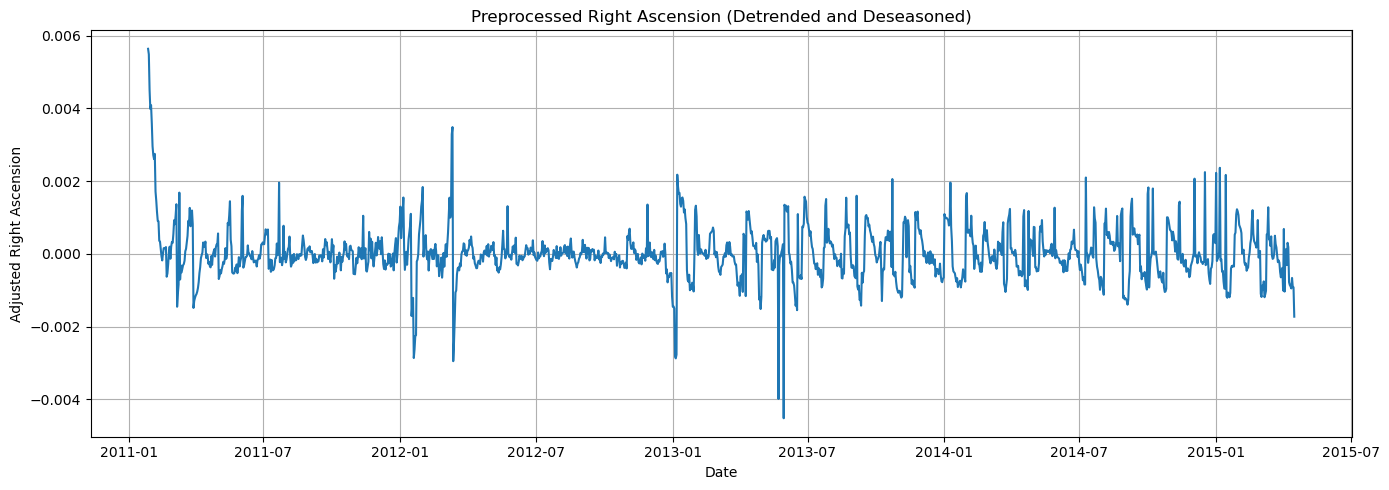

=== Preprocessed Series ===
ADF Statistic: -12.5723
p-value: 0.0000
Result: Stationary




In [15]:
# Checking stationarity and decomposing for right ascension

#  missing values in right ascension 
if orb_df['right ascension'].isna().sum() > 0:
    orb_df['right ascension'] = orb_df['right ascension'].fillna(method='ffill')

#  original right ascension trend
plt.figure(figsize=(14, 5))
plt.plot(orb_df.index, orb_df['right ascension'])
plt.title("Original Right Ascension Time Series")
plt.xlabel("Date")
plt.ylabel("Right Ascension")
plt.grid(True)
plt.tight_layout()
plt.show()

#  Stationarity check 
def test_stationarity(series, title):
    result = adfuller(series.dropna())
    print(f'=== {title} ===')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Result: {"Stationary" if result[1] < 0.05 else "Non-stationary"}')
    print("\n")
    return result[1] < 0.05

is_stationary = test_stationarity(orb_df['right ascension'], "Original Right Ascension")

#  Resample
ra_daily = orb_df['right ascension'].resample('D').mean().ffill()

#  Decompose 
period = 30  # Adjust as needed
decomposition = seasonal_decompose(ra_daily, model='additive', period=period)

#  decomposition ---
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.show()

# Preprocessing detrend and deseason 
trend = decomposition.trend.ffill().bfill()
seasonal = decomposition.seasonal.ffill().bfill()
detrended_deseasoned = ra_daily - trend - seasonal

#  preprocessed right ascension 
plt.figure(figsize=(14, 5))
plt.plot(detrended_deseasoned.index, detrended_deseasoned.values)
plt.title("Preprocessed Right Ascension (Detrended and Deseasoned)")
plt.xlabel("Date")
plt.ylabel("Adjusted Right Ascension")
plt.grid(True)
plt.tight_layout()
plt.show()

is_preprocessed_stationary = test_stationarity(detrended_deseasoned.dropna(), "Preprocessed Series")
preprocessed_data = detrended_deseasoned.dropna()

Train data shape: (1232,)
Test data shape: (309,)


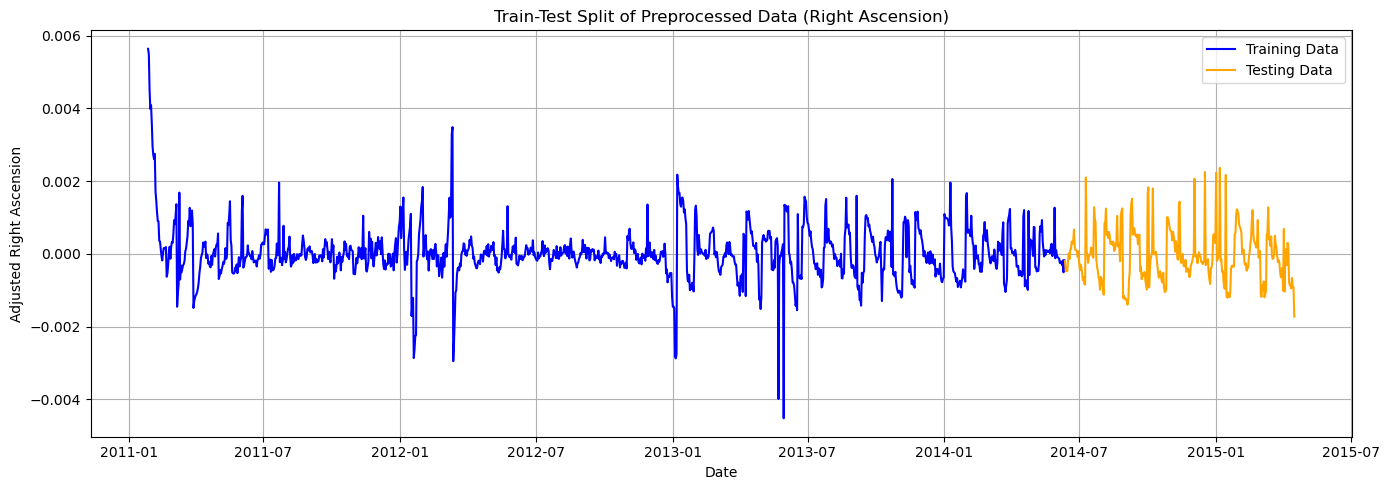

In [16]:
# Train-test split (80% train, 20% test)
train_size = int(len(preprocessed_data) * 0.8)
train_data = preprocessed_data[:train_size]
test_data = preprocessed_data[train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# split plot
plt.figure(figsize=(14, 5))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Testing Data', color='orange')
plt.title("Train-Test Split of Preprocessed Data (Right Ascension)")
plt.xlabel("Date")
plt.ylabel("Adjusted Right Ascension")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
#  Feature engineering function for right ascension 
def create_features(df, target_col='right ascension', lags=30):

    if isinstance(df, pd.Series):
        df = df.to_frame(name=target_col) 
    df = df.copy()  
    # Create temporal features
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year 
    #  lag features
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Drop rows with NaN
    df = df.dropna()  
    return df

right_ascension_features = create_features(preprocessed_data, target_col='right ascension', lags=30)
print(right_ascension_features.head())


            right ascension  dayofyear  quarter  month  year     lag_1  \
timestamp                                                                
2011-02-26        -0.000133         57        1      2  2011  0.000199   
2011-02-27         0.000197         58        1      2  2011 -0.000133   
2011-02-28         0.000328         59        1      2  2011  0.000197   
2011-03-01         0.000305         60        1      3  2011  0.000328   
2011-03-02         0.000553         61        1      3  2011  0.000305   

               lag_2     lag_3     lag_4     lag_5  ...    lag_21    lag_22  \
timestamp                                           ...                       
2011-02-26  0.000041 -0.000276 -0.000533 -0.000626  ...  0.002751  0.002608   
2011-02-27  0.000199  0.000041 -0.000276 -0.000533  ...  0.001715  0.002751   
2011-02-28 -0.000133  0.000199  0.000041 -0.000276  ...  0.001460  0.001715   
2011-03-01  0.000197 -0.000133  0.000199  0.000041  ...  0.001144  0.001460   
2011-03

In [18]:
# target column 
target_col = 'right ascension'

#  Create features for training and test data 
train_features = create_features(preprocessed_data[:train_size], target_col)
test_features = create_features(preprocessed_data[train_size:], target_col)

# Split into for training and testing
X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

# using MinMaxScaler 
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Features Shape: {X_train_scaled.shape}")
print(f"Test Features Shape: {X_test_scaled.shape}")

Training Features Shape: (1202, 34)
Test Features Shape: (279, 34)


In [19]:
# model setup
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# --- Parameter grid for GridSearch ---
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

#Cross Validation
tscv = TimeSeriesSplit(n_splits=3)

In [20]:
#  Grid Search 
grid_search = GridSearchCV(estimator=xgb_model,
                         param_grid=param_grid,
                         cv=tscv,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=1)
grid_search.fit(X_train_scaled, y_train)

# best model 
best_xgb = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [21]:
# final model
best_xgb.fit(X_train_scaled, y_train,
            eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
            verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [22]:
test_features = create_features(test_data, target_col)
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

In [23]:
#  Make predictions 
test_predictions = best_xgb.predict(X_test_scaled)


In [24]:
# RMSE 
train_predictions = best_xgb.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 0.0004
Test RMSE: 0.0006


In [25]:
print(len(test_data))
print(len(test_predictions))

309
279


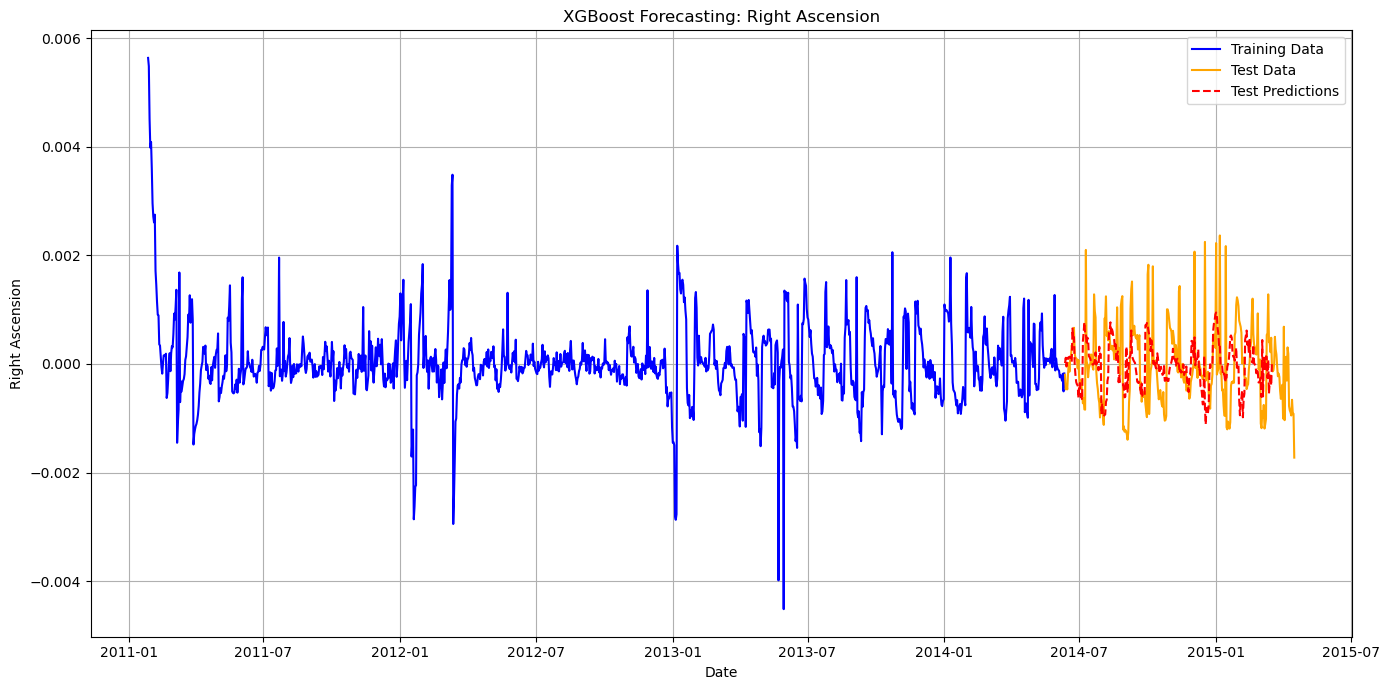

In [27]:
# Plot prediction vs observed
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Test Data', color='orange')
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Test Predictions', color='red', linestyle='--')  
plt.title("XGBoost Forecasting: Right Ascension")
plt.xlabel("Date")
plt.ylabel("Right Ascension")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


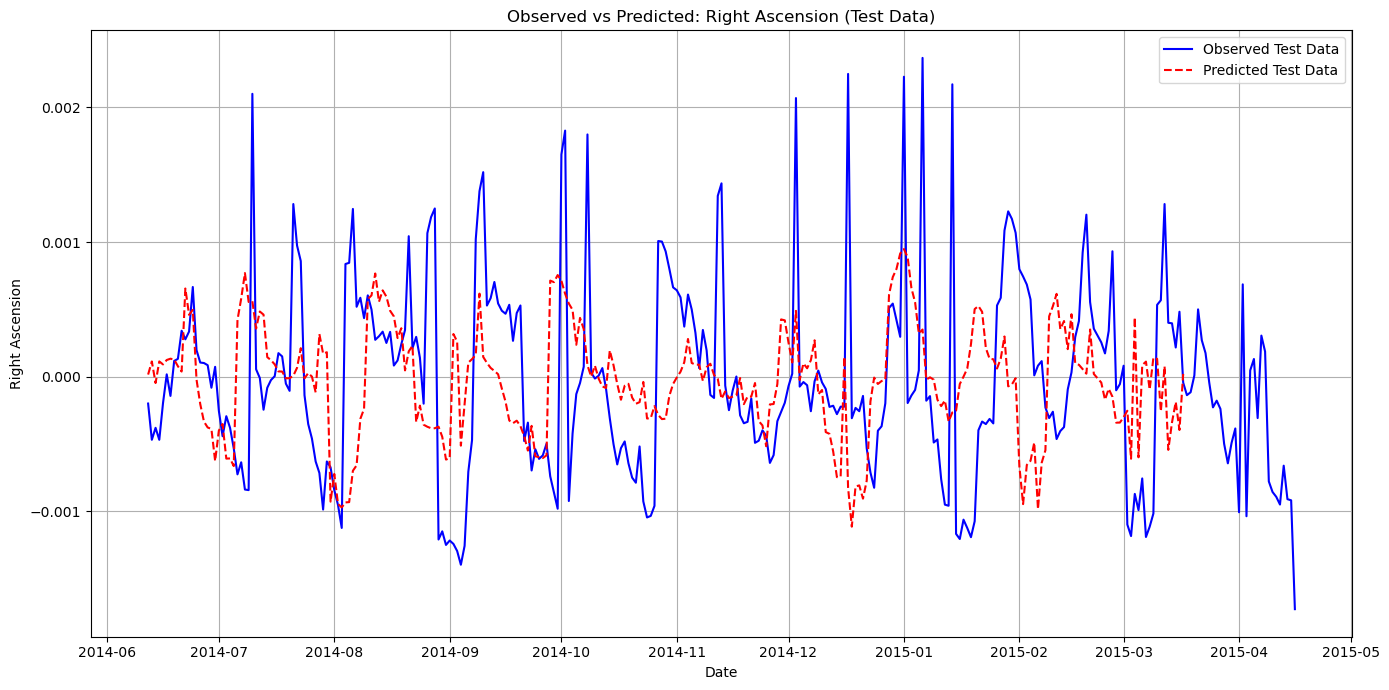

In [28]:
# observed vs predicted for "Right Ascension" test data 
plt.figure(figsize=(14, 7))

#  observed values
plt.plot(test_data.index, test_data, label='Observed Test Data', color='blue')

# predicted values
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Predicted Test Data', color='red', linestyle='--')

plt.title("Observed vs Predicted: Right Ascension (Test Data)")
plt.xlabel("Date")
plt.ylabel("Right Ascension")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


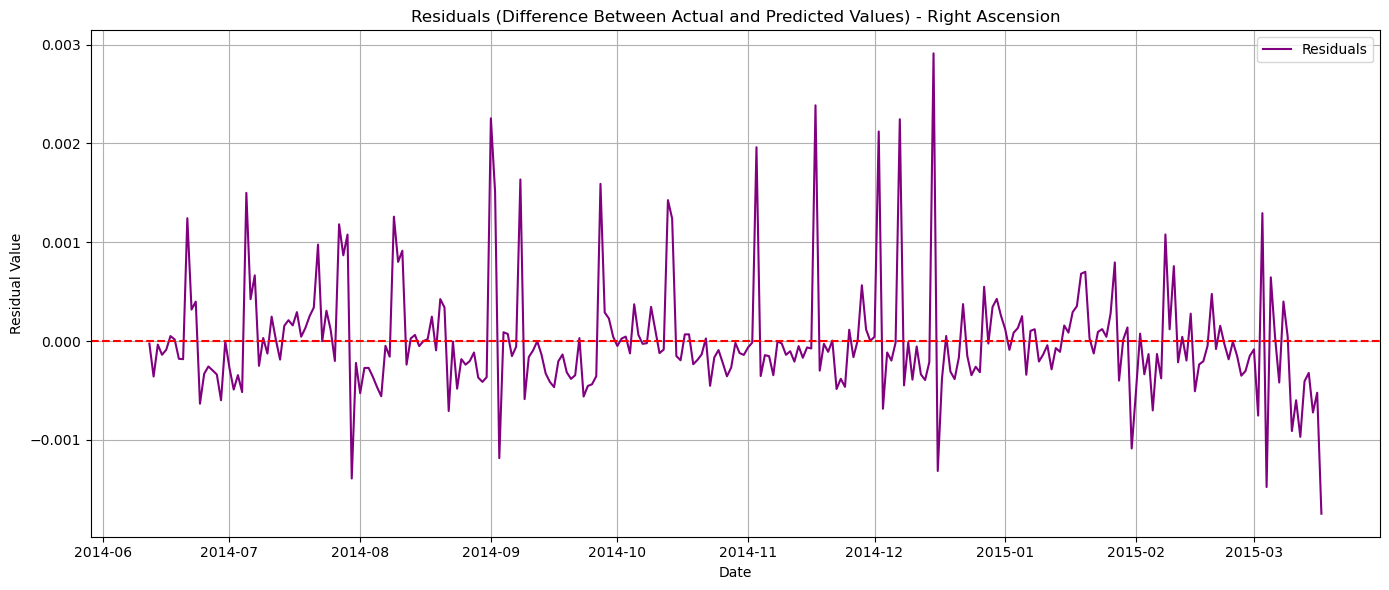

In [29]:
# Calculate residuals
residuals = y_test - test_predictions

# ploit
plt.figure(figsize=(14, 6))
plt.plot(test_data.index[:len(residuals)], residuals, label='Residuals', color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals (Difference Between Actual and Predicted Values) - Right Ascension')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
# Absolute Residuals
abs_residuals = np.abs(residuals)

#  Threshold 
threshold_std = abs_residuals.mean() + 2 * abs_residuals.std()
threshold = threshold_std  
print(f"Threshold value used: {threshold:.8f}")

# Detect Manoeuvres 
detected_manoeuvres = residuals[abs_residuals > threshold]
print(f"Number of detected manoeuvre points: {len(detected_manoeuvres)}")

#  Group detected points into events
detected_dates = detected_manoeuvres.index.tolist()
manoeuvre_events = []

if detected_dates:
    current_event = [detected_dates[0]]

    for i in range(1, len(detected_dates)):
        # If the gap between dates is <= 2 days,
        if (detected_dates[i] - current_event[-1]).days <= 2:
            current_event.append(detected_dates[i])
        else:
            # start a new one
            manoeuvre_events.append({
                'start_time': current_event[0],
                'end_time': current_event[-1],
                'max_residual': abs_residuals[current_event].max()
            })
            current_event = [detected_dates[i]]

    # last event
    manoeuvre_events.append({
        'start_time': current_event[0],
        'end_time': current_event[-1],
        'max_residual': abs_residuals[current_event].max()
    })
detected_df = pd.DataFrame(manoeuvre_events)

print("\nDetected Manoeuvre Events:")
print(detected_df)


Threshold value used: 0.00126200
Number of detected manoeuvre points: 16

Detected Manoeuvre Events:
   start_time   end_time  max_residual
0  2014-08-04 2014-08-04      0.001500
1  2014-08-29 2014-08-29      0.001390
2  2014-10-01 2014-10-02      0.002255
3  2014-10-08 2014-10-08      0.001636
4  2014-10-27 2014-10-27      0.001591
5  2014-11-12 2014-11-12      0.001427
6  2014-12-03 2014-12-03      0.001962
7  2014-12-17 2014-12-17      0.002386
8  2015-01-01 2015-01-01      0.002121
9  2015-01-06 2015-01-06      0.002245
10 2015-01-14 2015-01-15      0.002912
11 2015-04-02 2015-04-03      0.001477
12 2015-04-16 2015-04-16      0.001747


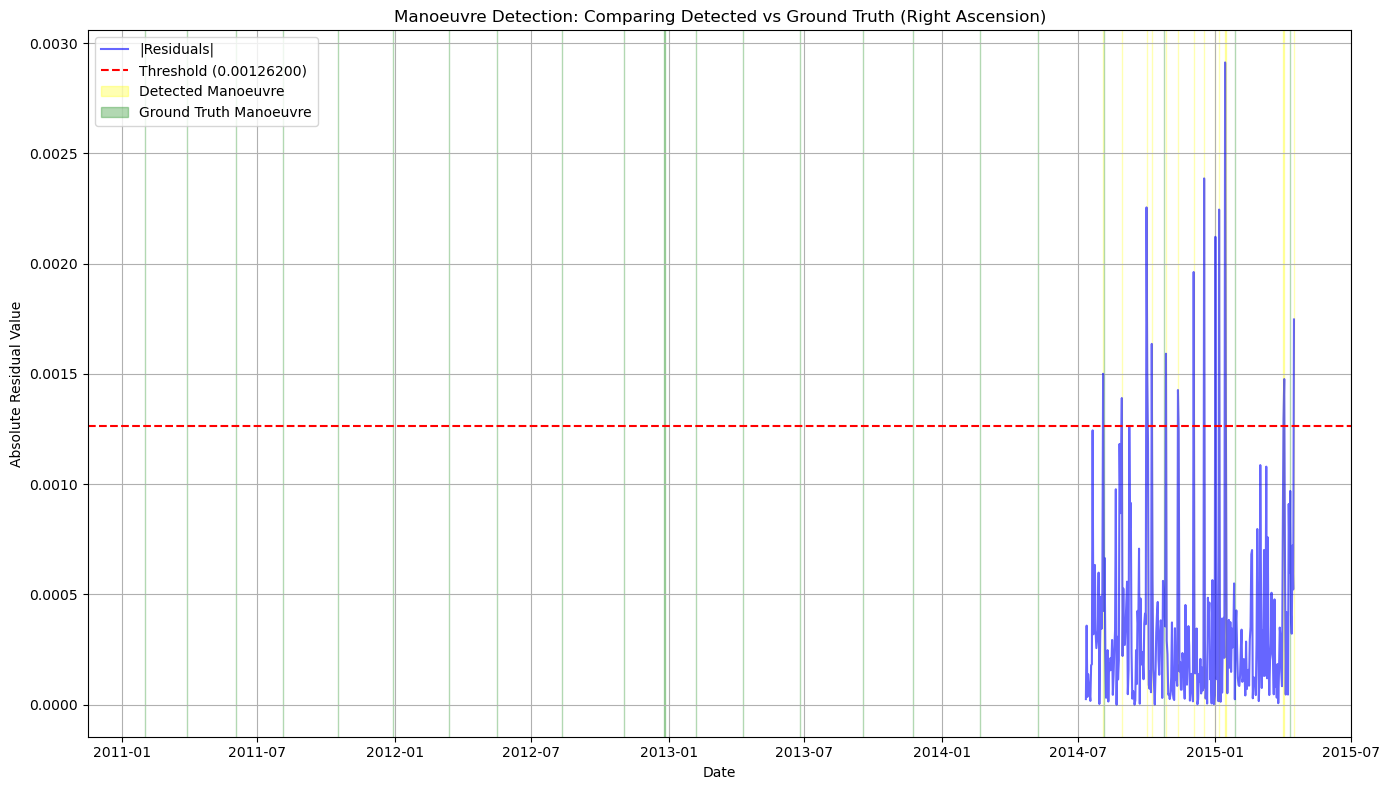

True Positives: 2
False Positives: 11
False Negatives: 20
Precision: 0.1538
Recall: 0.0909
F1 Score: 0.1143


In [31]:
# Detected Manoeuvres vs Ground Truth 
plt.figure(figsize=(14, 8))

# absolute residuals
plt.plot(abs_residuals.index, abs_residuals, label='|Residuals|', color='blue', alpha=0.6)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

# detected manoeuvre events
for idx, event in enumerate(manoeuvre_events):
    plt.axvspan(event['start_time'], event['end_time'], 
                alpha=0.3, color='yellow', label='Detected Manoeuvre' if idx == 0 else '')

#  ground truth manoeuvres 
for idx, row in man_df.iterrows():
    plt.axvspan(row['start_time'], row['end_time'], 
                alpha=0.3, color='green', label='Ground Truth Manoeuvre' if idx == 0 else '')

plt.title('Manoeuvre Detection: Comparing Detected vs Ground Truth (Right Ascension)')
plt.xlabel('Date')
plt.ylabel('Absolute Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Accuracy Metrics --
def calculate_detection_accuracy(detected_df, ground_truth_df, tolerance_days=3):

    true_positives = 0
    false_positives = 0
    for _, det_event in detected_df.iterrows():
        matched = False
        for _, gt_event in ground_truth_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break

        if matched:
            true_positives += 1
        else:
            false_positives += 1

    # False negatives
    false_negatives = 0
    for _, gt_event in ground_truth_df.iterrows():
        matched = False
        for _, det_event in detected_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break

        if not matched:
            false_negatives += 1

    # Metrics
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }

metrics = calculate_detection_accuracy(detected_df, man_df)
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"False Negatives: {metrics['false_negatives']}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")


In [32]:
#  summary tables 

# Detected Manoeuvres
print("\n[ XGBoost ] Detected Manoeuvres:")
print(detected_df[['start_time', 'end_time', 'max_residual']])

# Ground Truth Manoeuvres
print("\nGround Truth Manoeuvres:")
print(man_df[['start_time', 'end_time']])



[ XGBoost ] Detected Manoeuvres:
   start_time   end_time  max_residual
0  2014-08-04 2014-08-04      0.001500
1  2014-08-29 2014-08-29      0.001390
2  2014-10-01 2014-10-02      0.002255
3  2014-10-08 2014-10-08      0.001636
4  2014-10-27 2014-10-27      0.001591
5  2014-11-12 2014-11-12      0.001427
6  2014-12-03 2014-12-03      0.001962
7  2014-12-17 2014-12-17      0.002386
8  2015-01-01 2015-01-01      0.002121
9  2015-01-06 2015-01-06      0.002245
10 2015-01-14 2015-01-15      0.002912
11 2015-04-02 2015-04-03      0.001477
12 2015-04-16 2015-04-16      0.001747

Ground Truth Manoeuvres:
            start_time            end_time
0  2015-04-10 15:30:00 2015-04-10 16:30:00
1  2015-01-27 14:30:00 2015-01-27 15:30:00
2  2014-10-24 15:30:00 2014-10-24 16:30:00
3  2014-08-04 15:30:00 2014-08-04 16:30:00
4  2014-05-09 15:30:00 2014-05-09 16:30:00
5  2014-02-20 15:30:00 2014-02-20 16:30:00
6  2013-11-22 15:30:00 2013-11-22 16:30:00
7  2013-09-16 15:30:00 2013-09-16 16:30:00
8  2013

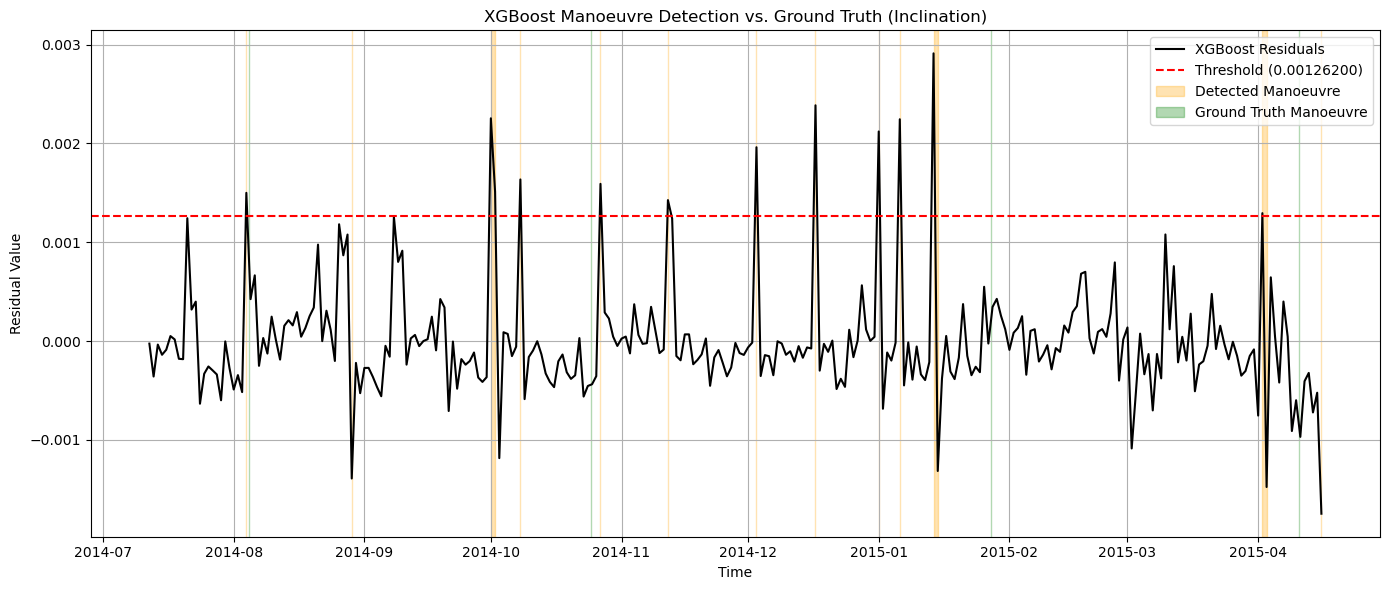

In [33]:
#  Filter ground truth manoeuvres
man_df_filtered = man_df[
    (man_df['start_time'] >= residuals.index.min()) &
    (man_df['end_time'] <= residuals.index.max())
]

plt.figure(figsize=(14, 6))

# residuals
plt.plot(residuals.index, residuals.values, label='XGBoost Residuals', color='black')

#  threshold line 
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

#  detected manoeuvres 
if not detected_df.empty:
    for idx, row in detected_df.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='orange', alpha=0.3,
                    label='Detected Manoeuvre' if idx == 0 else "")

#  ground truth manoeuvres 
if not man_df_filtered.empty:
    for idx, row in man_df_filtered.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.3,
                    label='Ground Truth Manoeuvre' if idx == 0 else "")

plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.title('XGBoost Manoeuvre Detection vs. Ground Truth (Inclination)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


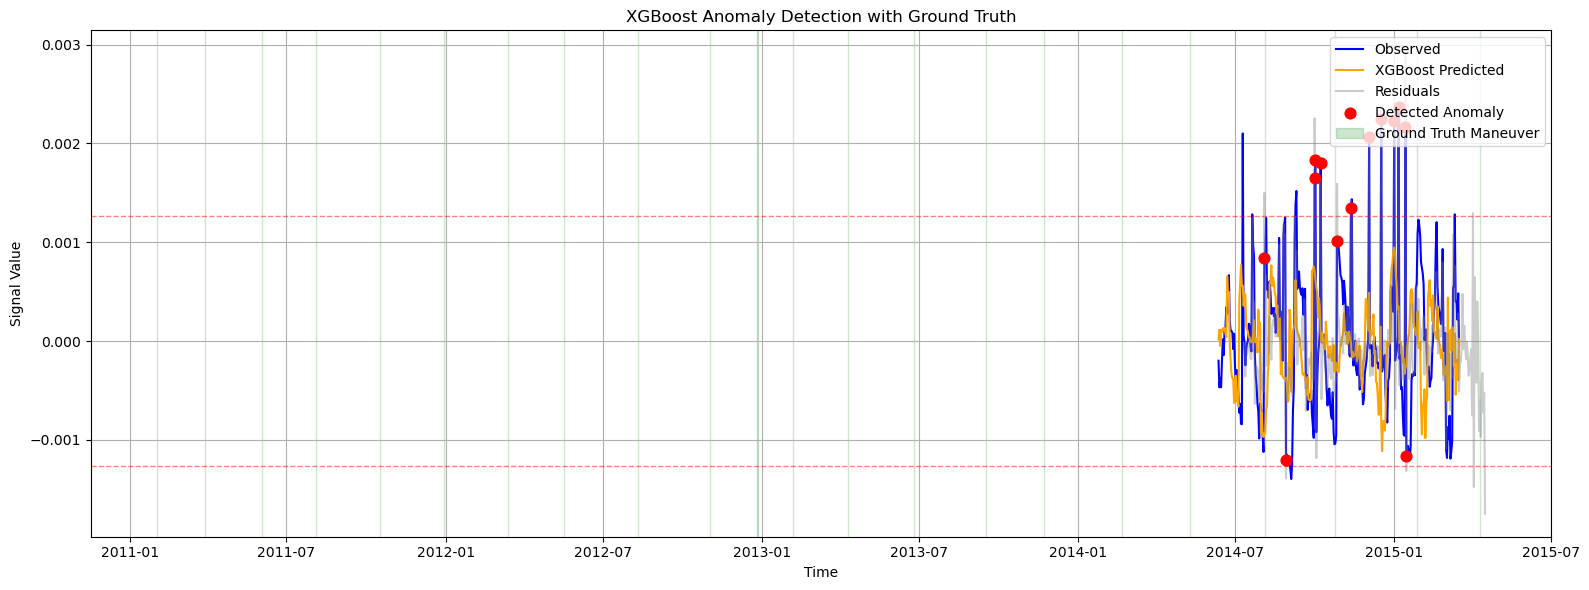

In [34]:

def detect_anomalies(residuals, threshold):
    anomaly_mask = residuals.abs() > threshold
    return residuals[anomaly_mask]

def plot_all_in_one_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        print(f"Warning: Length mismatch. Observed: {len(observed)}, Predicted: {len(predicted)}")
        min_len = min(len(observed), len(predicted))
        observed = observed[:min_len]
        predicted = predicted[:min_len]
        residuals = residuals[:min_len]

    predicted = pd.Series(predicted, index=observed.index)
    anomalies = detect_anomalies(residuals, threshold)

    anomalies = anomalies[anomalies.index.isin(observed.index)]
    fig, ax = plt.subplots(figsize=(16, 6))

    # Plot Observed and predicted
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)

    #  Plot residuals
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.4, label='Residuals')

    #  Plot anomalies 
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    #  Plot threshold lines 
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=-threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)

    # Ground Truth Maneuvers 
    for idx, row in man_df.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == 0 else "")
    ax.set_title("XGBoost Anomaly Detection with Ground Truth")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_all_in_one_xgboost(test_data, test_predictions, residuals, threshold, man_df)


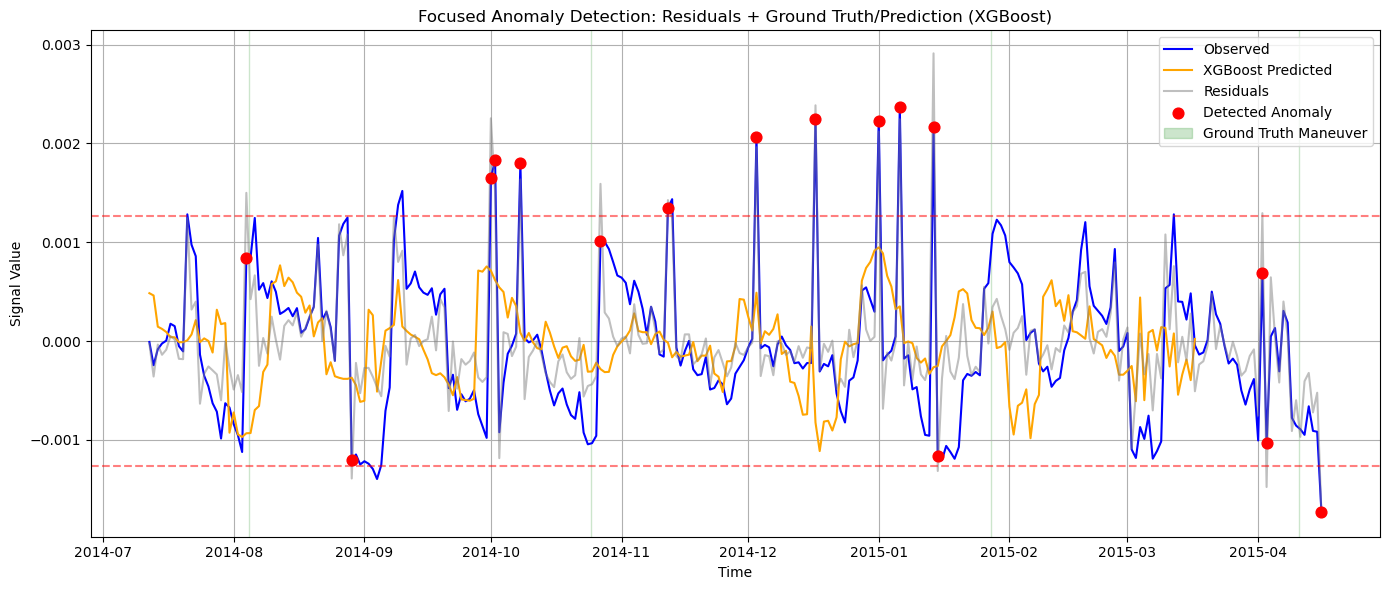

In [35]:
def plot_focused_anomalies_xgboost(observed, predicted, residuals, threshold, man_df):

    if len(predicted) != len(observed):
        predicted = pd.Series(predicted, index=observed.index[:len(predicted)])
    valid_times = residuals.dropna().index
    valid_man = man_df[
        (man_df['end_time'] >= valid_times.min()) &
        (man_df['start_time'] <= valid_times.max())
    ]

    #start and end time for plotting
    plot_start = max(valid_times.min(), predicted.dropna().index.min())
    plot_end = max(valid_times.max(), predicted.dropna().index.max())

    # Filter all data 
    observed = observed[(observed.index >= plot_start) & (observed.index <= plot_end)]
    predicted = predicted[(predicted.index >= plot_start) & (predicted.index <= plot_end)]
    residuals = residuals[(residuals.index >= plot_start) & (residuals.index <= plot_end)]
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[(anomalies.index >= plot_start) & (anomalies.index <= plot_end)]

    # Filter maneuvers
    valid_man = valid_man[
        (valid_man['start_time'] <= plot_end) &
        (valid_man['end_time'] >= plot_start)
    ]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))

    # Observed and Predicted 
    ax.plot(observed.index, observed.values, label='Observed', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted', color='orange', linewidth=1.5)
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.5, label='Residuals')

    # Detected anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # Residual threshold 
    ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
    ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

    # Ground truth  
    for idx, row in valid_man.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == valid_man.index[0] else "")

    ax.set_title("Focused Anomaly Detection: Residuals + Ground Truth/Prediction (XGBoost)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Signal Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
plot_focused_anomalies_xgboost(test_data, test_predictions, residuals, threshold, man_df)
